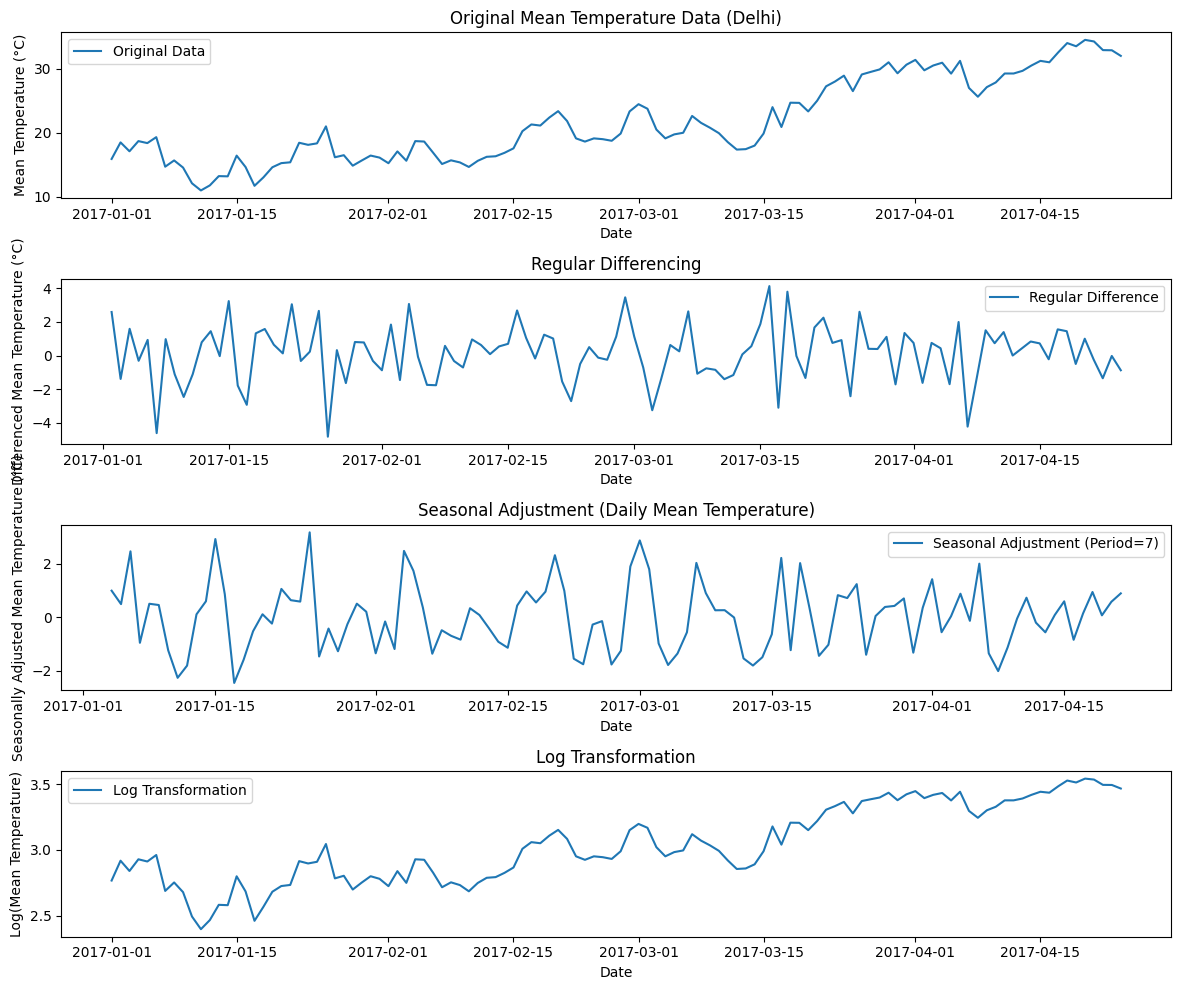

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

data = pd.read_csv('DailyDelhiClimate.csv')
data['date'] = pd.to_datetime(data['date'])
data.set_index('date', inplace=True)
data = data.sort_index()
data.index.freq = 'D' # Set frequency to daily

data['meantemp_diff'] = data['meantemp'].diff()
data['meantemp_log'] = np.log(data['meantemp'])
data['meantemp_log_diff'] = data['meantemp_log'].diff()

# For daily data, a period of 7 is appropriate for weekly seasonality
data['meantemp_sea_diff'] = seasonal_decompose(
    data['meantemp'], model='additive', period=7 # Changed period to 7 for weekly seasonality in daily data
).resid

data['meantemp_log_seasonal_diff'] = seasonal_decompose(
    data['meantemp_log_diff'].dropna(), model='additive', period=7 # Changed period to 7 for weekly seasonality
).resid


plt.figure(figsize=(12, 10))

plt.subplot(4, 1, 1)
plt.plot(data.index, data['meantemp'], label='Original Data')
plt.title('Original Mean Temperature Data (Delhi)')
plt.xlabel('Date')
plt.ylabel('Mean Temperature (°C)')
plt.legend()

plt.subplot(4, 1, 2)
plt.plot(data.index, data['meantemp_diff'], label='Regular Difference') 
plt.title('Regular Differencing')
plt.xlabel('Date')
plt.ylabel('Differenced Mean Temperature (°C)') 
plt.legend()

plt.subplot(4, 1, 3)
plt.plot(data.index, data['meantemp_sea_diff'], label='Seasonal Adjustment (Period=7)') 
plt.title('Seasonal Adjustment (Daily Mean Temperature)')
plt.xlabel('Date')
plt.ylabel('Seasonally Adjusted Mean Temperature (°C)') 
plt.legend()

plt.subplot(4, 1, 4)
plt.plot(data.index, data['meantemp_log'], label='Log Transformation') 
plt.title('Log Transformation')
plt.xlabel('Date')
plt.ylabel('Log(Mean Temperature)') 
plt.legend()

plt.tight_layout()
plt.show()